In [1]:
import pandas as pd


In [2]:
# ============================================================
# 1. LOAD DATASETS
# ============================================================

iscx = pd.read_csv(r"/Users/sheeba/Downloads/consolidated_traffic_data.csv")
darknet = pd.read_csv(r"/Users/sheeba/Desktop/ML PROJECT/Darknet.CSV")

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nISCX VPN-nonVPN:")
print("Shape:", iscx.shape)

print("\nCIC-Darknet2020:")
print("Shape:", darknet.shape)


DATASET OVERVIEW

ISCX VPN-nonVPN:
Shape: (59706, 24)

CIC-Darknet2020:
Shape: (158616, 85)


In [3]:
# ============================================================
# 2. DISPLAY COLUMN NAMES
# ============================================================

print("\n" + "=" * 70)
print("ISCX COLUMNS")
print("=" * 70)

for i, col in enumerate(iscx.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 70)
print("CIC-DARKNET2020 COLUMNS")
print("=" * 70)

for i, col in enumerate(darknet.columns, 1):
    print(f"{i}. {col}")



ISCX COLUMNS
1. duration
2. total_fiat
3. total_biat
4. min_fiat
5. min_biat
6. max_fiat
7. max_biat
8. mean_fiat
9. mean_biat
10. flowPktsPerSecond
11. flowBytesPerSecond
12. min_flowiat
13. max_flowiat
14. mean_flowiat
15. std_flowiat
16. min_active
17. mean_active
18. max_active
19. std_active
20. min_idle
21. mean_idle
22. max_idle
23. std_idle
24. traffic_type

CIC-DARKNET2020 COLUMNS
1. Flow ID
2. Src IP
3. Src Port
4. Dst IP
5. Dst Port
6. Protocol
7. Timestamp
8. Flow Duration
9. Total Fwd Packet
10. Total Bwd packets
11. Total Length of Fwd Packet
12. Total Length of Bwd Packet
13. Fwd Packet Length Max
14. Fwd Packet Length Min
15. Fwd Packet Length Mean
16. Fwd Packet Length Std
17. Bwd Packet Length Max
18. Bwd Packet Length Min
19. Bwd Packet Length Mean
20. Bwd Packet Length Std
21. Flow Bytes/s
22. Flow Packets/s
23. Flow IAT Mean
24. Flow IAT Std
25. Flow IAT Max
26. Flow IAT Min
27. Fwd IAT Total
28. Fwd IAT Mean
29. Fwd IAT Std
30. Fwd IAT Max
31. Fwd IAT Min
32. Bwd

In [4]:
# ============================================================
# 3. BASIC DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print("\nISCX missing values:")
print(iscx.isnull().sum()[iscx.isnull().sum() > 0])

print("\nDarknet missing values:")
print(darknet.isnull().sum()[darknet.isnull().sum() > 0])




MISSING VALUES

ISCX missing values:
Series([], dtype: int64)

Darknet missing values:
Flow Bytes/s    48
dtype: int64


In [5]:
# ============================================================
# 4. CHECK FOR INFINITE VALUES
# ============================================================

print("\n" + "=" * 70)
print("INFINITE VALUES")
print("=" * 70)

iscx_numeric = iscx.select_dtypes(include="number")
darknet_numeric = darknet.select_dtypes(include="number")

print("\nISCX infinite values:")
print(iscx_numeric.isin([float("inf"), float("-inf")]).sum().sum())

print("\nDarknet infinite values:")
print(darknet_numeric.isin([float("inf"), float("-inf")]).sum().sum())



INFINITE VALUES

ISCX infinite values:
0

Darknet infinite values:
52


In [6]:
# ============================================================
# 5. IDENTIFY THE 23 ISCX FEATURES
# ============================================================

iscx_features = [
    "duration",
    "total_fiat",
    "min_fiat",
    "max_fiat",
    "mean_fiat",
    "std_fiat",
    "total_biat",
    "min_biat",
    "max_biat",
    "mean_biat",
    "std_biat",
    "min_flowiat",
    "max_flowiat",
    "mean_flowiat",
    "std_flowiat",
    "min_active",
    "mean_active",
    "max_active",
    "std_active",
    "min_idle",
    "mean_idle",
    "max_idle",
    "std_idle"
]

print("\n" + "=" * 70)
print("ISCX 23-FEATURE CHECK")
print("=" * 70)

missing_iscx_features = [
    feature for feature in iscx_features
    if feature not in iscx.columns
]

if missing_iscx_features:
    print("WARNING: These ISCX features were not found:")
    for feature in missing_iscx_features:
        print("-", feature)
else:
    print("All 23 ISCX features found successfully.")



ISCX 23-FEATURE CHECK
- std_fiat
- std_biat


In [7]:
# ============================================================
# 6. MAP ISCX FEATURES TO CIC-DARKNET2020
# ============================================================

feature_mapping = {
    "duration": "Flow Duration",

    "total_fiat": "Fwd IAT Total",
    "min_fiat": "Fwd IAT Min",
    "max_fiat": "Fwd IAT Max",
    "mean_fiat": "Fwd IAT Mean",
    "std_fiat": "Fwd IAT Std",

    "total_biat": "Bwd IAT Total",
    "min_biat": "Bwd IAT Min",
    "max_biat": "Bwd IAT Max",
    "mean_biat": "Bwd IAT Mean",
    "std_biat": "Bwd IAT Std",

    "min_flowiat": "Flow IAT Min",
    "max_flowiat": "Flow IAT Max",
    "mean_flowiat": "Flow IAT Mean",
    "std_flowiat": "Flow IAT Std",

    "min_active": "Active Min",
    "mean_active": "Active Mean",
    "max_active": "Active Max",
    "std_active": "Active Std",

    "min_idle": "Idle Min",
    "mean_idle": "Idle Mean",
    "max_idle": "Idle Max",
    "std_idle": "Idle Std"
}


In [8]:
# ============================================================
# 7. FEATURE COMPATIBILITY TABLE
# ============================================================

print("\n" + "=" * 70)
print("FEATURE COMPATIBILITY")
print("=" * 70)

comparison_rows = []

for iscx_feature, darknet_feature in feature_mapping.items():

    iscx_exists = iscx_feature in iscx.columns
    darknet_exists = darknet_feature in darknet.columns

    if iscx_exists and darknet_exists:
        status = "MATCH"
    elif iscx_exists and not darknet_exists:
        status = "MISSING IN DARKNET"
    elif not iscx_exists and darknet_exists:
        status = "MISSING IN ISCX"
    else:
        status = "MISSING IN BOTH"

    comparison_rows.append({
        "ISCX Feature": iscx_feature,
        "Darknet Feature": darknet_feature,
        "ISCX Present": iscx_exists,
        "Darknet Present": darknet_exists,
        "Status": status
    })

feature_comparison = pd.DataFrame(comparison_rows)

print(feature_comparison.to_string(index=False))



FEATURE COMPATIBILITY
ISCX Feature Darknet Feature  ISCX Present  Darknet Present          Status
    duration   Flow Duration          True             True           MATCH
  total_fiat   Fwd IAT Total          True             True           MATCH
    min_fiat     Fwd IAT Min          True             True           MATCH
    max_fiat     Fwd IAT Max          True             True           MATCH
   mean_fiat    Fwd IAT Mean          True             True           MATCH
    std_fiat     Fwd IAT Std         False             True MISSING IN ISCX
  total_biat   Bwd IAT Total          True             True           MATCH
    min_biat     Bwd IAT Min          True             True           MATCH
    max_biat     Bwd IAT Max          True             True           MATCH
   mean_biat    Bwd IAT Mean          True             True           MATCH
    std_biat     Bwd IAT Std         False             True MISSING IN ISCX
 min_flowiat    Flow IAT Min          True             True      

In [9]:
# ============================================================
# 8. SUMMARY OF FEATURE COMPATIBILITY
# ============================================================

matched_features = feature_comparison[
    feature_comparison["Status"] == "MATCH"
]

print("\n" + "=" * 70)
print("FEATURE COMPATIBILITY SUMMARY")
print("=" * 70)

print("Total ISCX features:", len(iscx_features))
print("Matching features:", len(matched_features))
print(
    "Compatibility:",
    f"{len(matched_features) / len(iscx_features) * 100:.2f}%"
)



FEATURE COMPATIBILITY SUMMARY
Total ISCX features: 23
Matching features: 21
Compatibility: 91.30%


In [10]:
# ============================================================
# 9. CHECK ISCX LABEL COLUMN
# ============================================================

print("\n" + "=" * 70)
print("ISCX LABEL COLUMNS")
print("=" * 70)

print(iscx.columns.tolist())

print("\nPossible categorical columns and their unique values:")

for col in iscx.select_dtypes(include="object").columns:

    unique_count = iscx[col].nunique()

    if unique_count <= 30:
        print(f"\n{col}:")
        print(iscx[col].value_counts(dropna=False))



ISCX LABEL COLUMNS
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle', 'traffic_type']

Possible categorical columns and their unique values:

traffic_type:
traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64


In [11]:
# ============================================================
# 10. DARKNET LABEL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("DARKNET LABEL DISTRIBUTION")
print("=" * 70)

print("\nLabel:")
print(darknet["Label"].value_counts(dropna=False))

print("\nLabel.1:")
print(darknet["Label.1"].value_counts(dropna=False))




DARKNET LABEL DISTRIBUTION

Label:
Label
Non-Tor    110442
NonVPN      23863
VPN         22919
Tor          1392
Name: count, dtype: int64

Label.1:
Label.1
P2P                48520
Browsing           46457
Audio-Streaming    19830
Chat               11629
File-Transfer      11098
Video-Streaming     9486
Email               6145
VOIP                3566
AUDIO-STREAMING     1520
Video-streaming      281
File-transfer         84
Name: count, dtype: int64


In [12]:
# ============================================================
# 11. STANDARDIZE DARKNET APPLICATION LABELS
# ============================================================

darknet["Application"] = (
    darknet["Label.1"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\n" + "=" * 70)
print("STANDARDIZED DARKNET APPLICATION CATEGORIES")
print("=" * 70)

print(darknet["Application"].value_counts())




STANDARDIZED DARKNET APPLICATION CATEGORIES
Application
p2p                48520
browsing           46457
audio-streaming    21350
chat               11629
file-transfer      11182
video-streaming     9767
email               6145
voip                3566
Name: count, dtype: int64


In [13]:
# ============================================================
# 12. CROSS-TABULATION:
#     APPLICATION TYPE vs VPN/TOR TYPE
# ============================================================

print("\n" + "=" * 70)
print("DARKNET APPLICATION × NETWORK TYPE")
print("=" * 70)

cross_tab = pd.crosstab(
    darknet["Application"],
    darknet["Label"]
)

print(cross_tab)



DARKNET APPLICATION × NETWORK TYPE
Label            Non-Tor  NonVPN  Tor    VPN
Application                                 
audio-streaming     4770    3296  224  13060
browsing           46194       0  263      0
chat                 564    6524   65   4476
email                492    5071   13    569
file-transfer       6740    1832  107   2503
p2p                48300       0  220      0
video-streaming     3382    5039  202   1144
voip                   0    2101  298   1167


In [14]:
# ============================================================
# 13. CHECK WHETHER DARKNET CAN RECREATE
#     THE ISCX-STYLE LABELS
# ============================================================

print("\n" + "=" * 70)
print("POTENTIAL ISCX-STYLE LABEL MAPPING")
print("=" * 70)

application_mapping = {
    "browsing": "BROWSING",
    "chat": "CHAT",
    "voip": "VOIP",
    "p2p": "P2P",
    "email": "MAIL",
    "file-transfer": "FT",
    "audio-streaming": "STREAMING",
    "video-streaming": "STREAMING"
}

for application, iscx_name in application_mapping.items():

    if application in cross_tab.index:

        print(f"\n{application.upper()} -> {iscx_name}")

        for network_type in cross_tab.columns:
            count = cross_tab.loc[application, network_type]
            print(f"    {network_type}: {count}")





POTENTIAL ISCX-STYLE LABEL MAPPING

BROWSING -> BROWSING
    Non-Tor: 46194
    NonVPN: 0
    Tor: 263
    VPN: 0

CHAT -> CHAT
    Non-Tor: 564
    NonVPN: 6524
    Tor: 65
    VPN: 4476

VOIP -> VOIP
    Non-Tor: 0
    NonVPN: 2101
    Tor: 298
    VPN: 1167

P2P -> P2P
    Non-Tor: 48300
    NonVPN: 0
    Tor: 220
    VPN: 0

EMAIL -> MAIL
    Non-Tor: 492
    NonVPN: 5071
    Tor: 13
    VPN: 569

FILE-TRANSFER -> FT
    Non-Tor: 6740
    NonVPN: 1832
    Tor: 107
    VPN: 2503

AUDIO-STREAMING -> STREAMING
    Non-Tor: 4770
    NonVPN: 3296
    Tor: 224
    VPN: 13060

VIDEO-STREAMING -> STREAMING
    Non-Tor: 3382
    NonVPN: 5039
    Tor: 202
    VPN: 1144


In [15]:
# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL COMPATIBILITY SUMMARY")
print("=" * 70)

print(
    f"""
ISCX dataset:
    Rows: {len(iscx):,}
    Columns: {len(iscx.columns)}

CIC-Darknet2020:
    Rows: {len(darknet):,}
    Columns: {len(darknet.columns)}

ISCX features examined:
    {len(iscx_features)}

Matching Darknet features:
    {len(matched_features)}

Feature compatibility:
    {len(matched_features) / len(iscx_features) * 100:.2f}%

Next step:
    Verify whether Darknet labels can be mapped
    legitimately to the ISCX classification scheme.
"""
)


FINAL COMPATIBILITY SUMMARY

ISCX dataset:
    Rows: 59,706
    Columns: 24

CIC-Darknet2020:
    Rows: 158,616
    Columns: 86

ISCX features examined:
    23

Matching Darknet features:
    21

Feature compatibility:
    91.30%

Next step:
    Verify whether Darknet labels can be mapped
    legitimately to the ISCX classification scheme.



In [16]:
print("=" * 70)
print("DARKNET APPLICATION × NETWORK TYPE — PERCENTAGES")
print("=" * 70)

cross_tab_percent = pd.crosstab(
    darknet["Application"],
    darknet["Label"],
    normalize="index"
) * 100

print(cross_tab_percent.round(2))

DARKNET APPLICATION × NETWORK TYPE — PERCENTAGES
Label            Non-Tor  NonVPN   Tor    VPN
Application                                  
audio-streaming    22.34   15.44  1.05  61.17
browsing           99.43    0.00  0.57   0.00
chat                4.85   56.10  0.56  38.49
email               8.01   82.52  0.21   9.26
file-transfer      60.28   16.38  0.96  22.38
p2p                99.55    0.00  0.45   0.00
video-streaming    34.63   51.59  2.07  11.71
voip                0.00   58.92  8.36  32.73


In [ ]:
print("\n" + "=" * 70)
print("DARKNET LABEL COMBINATIONS")
print("=" * 70)

combination_counts = (
    darknet.groupby(["Application", "Label"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Application", "Label"])
)

print(combination_counts.to_string(index=False))


DARKNET LABEL COMBINATIONS
    Application   Label  Count
audio-streaming Non-Tor   4770
audio-streaming  NonVPN   3296
audio-streaming     Tor    224
audio-streaming     VPN  13060
       browsing Non-Tor  46194
       browsing     Tor    263
           chat Non-Tor    564
           chat  NonVPN   6524
           chat     Tor     65
           chat     VPN   4476
          email Non-Tor    492
          email  NonVPN   5071
          email     Tor     13
          email     VPN    569
  file-transfer Non-Tor   6740
  file-transfer  NonVPN   1832
  file-transfer     Tor    107
  file-transfer     VPN   2503
            p2p Non-Tor  48300
            p2p     Tor    220
video-streaming Non-Tor   3382
video-streaming  NonVPN   5039
video-streaming     Tor    202
video-streaming     VPN   1144
           voip  NonVPN   2101
           voip     Tor    298
           voip     VPN   1167


==================EXPERIMENT===================

In [3]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import load_model

print("Environment ready!")

Environment ready!


In [5]:
# Project paths

PROJECT_ROOT = os.path.abspath("..")

ISCX_X_TRAIN_PATH = os.path.join(
    PROJECT_ROOT, "data", "processed", "X_train.csv"
)

DARKNET_PATH = os.path.join(
    PROJECT_ROOT, "data", "raw", "CICDarknet2020.csv"
)

LABEL_MAPPING_PATH = os.path.join(
    PROJECT_ROOT, "data", "processed", "label_mapping.json"
)

RF_MODEL_PATH = os.path.join(
    PROJECT_ROOT, "models", "rf_model.pkl"
)

XGB_MODEL_PATH = os.path.join(
    PROJECT_ROOT, "models", "xgboost_model.pkl"
)

CNN_MODEL_PATH = os.path.join(
    PROJECT_ROOT, "models", "cnn_model.h5"
)

LSTM_MODEL_PATH = os.path.join(
    PROJECT_ROOT, "models", "lstm_model.h5"
)

print("Project root:", PROJECT_ROOT)
print("Darknet path:", DARKNET_PATH)

Project root: /Users/sheeba/Desktop/ML PROJECT/encrypted-traffic-classifier-xai
Darknet path: /Users/sheeba/Desktop/ML PROJECT/encrypted-traffic-classifier-xai/data/raw/CICDarknet2020.csv


In [6]:
X_train_iscx = pd.read_csv(ISCX_X_TRAIN_PATH)

print("ISCX training shape:", X_train_iscx.shape)
print("\nISCX feature columns:")
print(X_train_iscx.columns.tolist())

ISCX training shape: (47764, 23)

ISCX feature columns:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']


In [7]:
darknet = pd.read_csv(r"/Users/sheeba/Desktop/ML PROJECT/Darknet.CSV")

print("Darknet2020 shape:", darknet.shape)
print("\nFirst 5 rows:")
display(darknet.head())

Darknet2020 shape: (158616, 85)

First 5 rows:


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,Non-Tor,AUDIO-STREAMING


In [8]:
darknet.columns = darknet.columns.str.strip()

print(darknet.columns.tolist())

['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',

In [9]:
required_darknet_columns = [
    "Flow Duration",
    "Fwd IAT Total",
    "Fwd IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Mean",
    "Bwd IAT Total",
    "Bwd IAT Min",
    "Bwd IAT Max",
    "Bwd IAT Mean",
    "Flow Packets/s",
    "Flow Bytes/s",
    "Flow IAT Min",
    "Flow IAT Max",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Active Min",
    "Active Mean",
    "Active Max",
    "Active Std",
    "Idle Min",
    "Idle Mean",
    "Idle Max",
    "Idle Std"
]

missing_columns = [
    col for col in required_darknet_columns
    if col not in darknet.columns
]

print("Missing required columns:", missing_columns)

Missing required columns: []


In [10]:
feature_mapping = {
    "duration": "Flow Duration",
    
    "total_fiat": "Fwd IAT Total",
    "min_fiat": "Fwd IAT Min",
    "max_fiat": "Fwd IAT Max",
    "mean_fiat": "Fwd IAT Mean",
    
    "total_biat": "Bwd IAT Total",
    "min_biat": "Bwd IAT Min",
    "max_biat": "Bwd IAT Max",
    "mean_biat": "Bwd IAT Mean",
    
    "flowPktsPerSecond": "Flow Packets/s",
    "flowBytesPerSecond": "Flow Bytes/s",
    
    "min_flowiat": "Flow IAT Min",
    "max_flowiat": "Flow IAT Max",
    "mean_flowiat": "Flow IAT Mean",
    "std_flowiat": "Flow IAT Std",
    
    "min_active": "Active Min",
    "mean_active": "Active Mean",
    "max_active": "Active Max",
    "std_active": "Active Std",
    
    "min_idle": "Idle Min",
    "mean_idle": "Idle Mean",
    "max_idle": "Idle Max",
    "std_idle": "Idle Std"
}

print("Number of mapped features:", len(feature_mapping))

Number of mapped features: 23


In [11]:
iscx_features = X_train_iscx.columns.tolist()

print("ISCX features:", len(iscx_features))
print("Mapped features:", len(feature_mapping))

print("\nISCX feature order:")
for i, feature in enumerate(iscx_features, start=1):
    print(f"{i}. {feature} -> {feature_mapping.get(feature)}")

ISCX features: 23
Mapped features: 23

ISCX feature order:
1. duration -> Flow Duration
2. total_fiat -> Fwd IAT Total
3. total_biat -> Bwd IAT Total
4. min_fiat -> Fwd IAT Min
5. min_biat -> Bwd IAT Min
6. max_fiat -> Fwd IAT Max
7. max_biat -> Bwd IAT Max
8. mean_fiat -> Fwd IAT Mean
9. mean_biat -> Bwd IAT Mean
10. flowPktsPerSecond -> Flow Packets/s
11. flowBytesPerSecond -> Flow Bytes/s
12. min_flowiat -> Flow IAT Min
13. max_flowiat -> Flow IAT Max
14. mean_flowiat -> Flow IAT Mean
15. std_flowiat -> Flow IAT Std
16. min_active -> Active Min
17. mean_active -> Active Mean
18. max_active -> Active Max
19. std_active -> Active Std
20. min_idle -> Idle Min
21. mean_idle -> Idle Mean
22. max_idle -> Idle Max
23. std_idle -> Idle Std


In [12]:
X_darknet = pd.DataFrame({
    iscx_feature: darknet[feature_mapping[iscx_feature]]
    for iscx_feature in iscx_features
})

print("Darknet feature matrix shape:", X_darknet.shape)
display(X_darknet.head())

Darknet feature matrix shape: (158616, 23)


,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,mean_flowiat,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle
0,229,0,0,0,0,0,0,0.000000,0.000000,8733.624454,...,229.000000,0.000000,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,407,0,0,0,0,0,0,0.000000,0.000000,4914.004914,...,407.000000,0.000000,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,431,0,0,0,0,0,0,0.000000,0.000000,4640.371230,...,431.000000,0.000000,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,359,0,0,0,0,0,0,0.000000,0.000000,5571.030641,...,359.000000,0.000000,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,10778451,10778451,10747836,126,307,81171,78158,18268.561017,26936.932331,91.942711,...,10887.324242,11412.466412,0,0,0,0,1.437765e+15,1.437765e+15,1.437765e+15,3.117718e+06


In [13]:
print("NaN values:")
print(X_darknet.isna().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_darknet.select_dtypes(include=np.number)).sum().sum())

NaN values:
48

Infinite values:
52


In [14]:
valid_mask = (
    X_darknet.notna().all(axis=1)
    & ~np.isinf(X_darknet).any(axis=1)
)

print("Total rows:", len(X_darknet))
print("Valid rows:", valid_mask.sum())
print("Removed rows:", (~valid_mask).sum())

Total rows: 158616
Valid rows: 158566
Removed rows: 50


In [15]:
X_darknet_clean = X_darknet.loc[valid_mask].copy()

darknet_clean = darknet.loc[valid_mask].copy()

print("Cleaned feature shape:", X_darknet_clean.shape)
print("Cleaned Darknet shape:", darknet_clean.shape)

Cleaned feature shape: (158566, 23)
Cleaned Darknet shape: (158566, 85)


In [18]:
with open(LABEL_MAPPING_PATH, "r") as f:
    label_mapping = json.load(f)

print("Number of classes:", len(label_mapping))
print(label_mapping)

Number of classes: 14
{'BROWSING': 0, 'CHAT': 1, 'FT': 2, 'MAIL': 3, 'P2P': 4, 'STREAMING': 5, 'VOIP': 6, 'VPN-BROWSING': 7, 'VPN-CHAT': 8, 'VPN-FT': 9, 'VPN-MAIL': 10, 'VPN-P2P': 11, 'VPN-STREAMING': 12, 'VPN-VOIP': 13}


In [19]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Train RF on the ORIGINAL ISCX training data
# This reproduces the existing RF training configuration.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_iscx, np.load(
    os.path.join(PROJECT_ROOT, "data", "processed", "y_train.npy")
))

# Train XGBoost on the ORIGINAL ISCX training data
y_train_iscx = np.load(
    os.path.join(PROJECT_ROOT, "data", "processed", "y_train.npy")
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_mapping),
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train_iscx, y_train_iscx)

print("RF and XGBoost models ready!")

RF and XGBoost models ready!


In [20]:
cnn_model = load_model(CNN_MODEL_PATH)
lstm_model = load_model(LSTM_MODEL_PATH)

print("CNN and LSTM loaded successfully!")

CNN and LSTM loaded successfully!


In [21]:
scaler = StandardScaler()

# Fit ONLY on the original ISCX training data
scaler.fit(X_train_iscx.values)

# Transform Darknet using the ISCX-fitted scaler
X_darknet_scaled = scaler.transform(X_darknet_clean.values)

print("Scaled Darknet shape:", X_darknet_scaled.shape)

Scaled Darknet shape: (158566, 23)


In [22]:
# Random Forest + XGBoost
X_darknet_tree = X_darknet_clean.values

# CNN: (samples, 23, 1)
X_darknet_cnn = X_darknet_scaled.reshape(
    X_darknet_scaled.shape[0],
    X_darknet_scaled.shape[1],
    1
)

# LSTM: (samples, 1, 23)
X_darknet_lstm = X_darknet_scaled.reshape(
    X_darknet_scaled.shape[0],
    1,
    X_darknet_scaled.shape[1]
)

print("Tree input:", X_darknet_tree.shape)
print("CNN input:", X_darknet_cnn.shape)
print("LSTM input:", X_darknet_lstm.shape)

Tree input: (158566, 23)
CNN input: (158566, 23, 1)
LSTM input: (158566, 1, 23)


In [23]:
print("Running Random Forest...")
rf_pred = rf_model.predict(X_darknet_tree)

print("Running XGBoost...")
xgb_pred = xgb_model.predict(X_darknet_tree)

print("Running CNN...")
cnn_pred_prob = cnn_model.predict(X_darknet_cnn, verbose=0)
cnn_pred = np.argmax(cnn_pred_prob, axis=1)

print("Running LSTM...")
lstm_pred_prob = lstm_model.predict(X_darknet_lstm, verbose=0)
lstm_pred = np.argmax(lstm_pred_prob, axis=1)

print("\nAll four models generated predictions successfully!")

Running Random Forest...


/opt/anaconda3/envs/traffic-classifier/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Running XGBoost...
Running CNN...
Running LSTM...

All four models generated predictions successfully!


In [24]:
# Convert numeric predictions to class names

with open(LABEL_MAPPING_PATH, "r") as f:
    label_mapping = json.load(f)

int_to_label = {int(value): key for key, value in label_mapping.items()}

rf_labels = [int_to_label[int(x)] for x in rf_pred]
xgb_labels = [int_to_label[int(x)] for x in xgb_pred]
cnn_labels = [int_to_label[int(x)] for x in cnn_pred]
lstm_labels = [int_to_label[int(x)] for x in lstm_pred]

print("RF sample:", rf_labels[:10])
print("XGBoost sample:", xgb_labels[:10])
print("CNN sample:", cnn_labels[:10])
print("LSTM sample:", lstm_labels[:10])

RF sample: ['FT', 'FT', 'FT', 'FT', 'VOIP', 'VPN-BROWSING', 'VPN-BROWSING', 'BROWSING', 'VPN-BROWSING', 'FT']
XGBoost sample: ['FT', 'FT', 'FT', 'FT', 'VOIP', 'VPN-CHAT', 'VPN-BROWSING', 'BROWSING', 'VPN-BROWSING', 'VOIP']
CNN sample: ['FT', 'FT', 'FT', 'FT', 'VPN-FT', 'VPN-FT', 'VPN-FT', 'VPN-FT', 'VPN-FT', 'VPN-FT']
LSTM sample: ['FT', 'FT', 'FT', 'FT', 'FT', 'FT', 'FT', 'FT', 'FT', 'FT']


In [25]:
# Create results dataframe

results = darknet_clean.copy()

results["RF_Prediction"] = rf_labels
results["XGBoost_Prediction"] = xgb_labels
results["CNN_Prediction"] = cnn_labels
results["LSTM_Prediction"] = lstm_labels

print("Results shape:", results.shape)

results[
    [
        "RF_Prediction",
        "XGBoost_Prediction",
        "CNN_Prediction",
        "LSTM_Prediction"
    ]
].head(10)

Results shape: (158566, 89)


,RF_Prediction,XGBoost_Prediction,CNN_Prediction,LSTM_Prediction
0,FT,FT,FT,FT
1,FT,FT,FT,FT
2,FT,FT,FT,FT
3,FT,FT,FT,FT
4,VOIP,VOIP,VPN-FT,FT
5,VPN-BROWSING,VPN-CHAT,VPN-FT,FT
6,VPN-BROWSING,VPN-BROWSING,VPN-FT,FT
7,BROWSING,BROWSING,VPN-FT,FT
8,VPN-BROWSING,VPN-BROWSING,VPN-FT,FT
9,FT,VOIP,VPN-FT,FT


In [26]:
# Prediction distribution for each model

print("===== RANDOM FOREST =====")
print(results["RF_Prediction"].value_counts())

print("\n===== XGBOOST =====")
print(results["XGBoost_Prediction"].value_counts())

print("\n===== CNN =====")
print(results["CNN_Prediction"].value_counts())

print("\n===== LSTM =====")
print(results["LSTM_Prediction"].value_counts())

===== RANDOM FOREST =====
RF_Prediction
VPN-BROWSING     40629
BROWSING         29676
VPN-P2P          25408
VPN-FT           15198
P2P              12106
VPN-VOIP         10986
FT                7522
MAIL              5313
VOIP              3326
VPN-CHAT          2131
VPN-STREAMING     2033
VPN-MAIL          1835
CHAT              1536
STREAMING          867
Name: count, dtype: int64

===== XGBOOST =====
XGBoost_Prediction
FT               39701
BROWSING         30258
VPN-P2P          27350
VPN-BROWSING     20602
P2P              11978
VPN-FT            4811
MAIL              4563
VPN-VOIP          4470
STREAMING         4087
VOIP              3608
VPN-CHAT          3518
VPN-STREAMING     1397
VPN-MAIL          1369
CHAT               854
Name: count, dtype: int64

===== CNN =====
CNN_Prediction
VPN-FT           66521
FT               26011
VPN-P2P          21741
BROWSING         15482
P2P              10677
MAIL              7077
VPN-MAIL          4798
VPN-BROWSING      3278
VPN-VOIP

In [27]:
def iscx_to_application(label):
    label = str(label).upper()

    if "BROWSING" in label:
        return "browsing"
    elif "CHAT" in label:
        return "chat"
    elif "VOIP" in label:
        return "voip"
    elif "P2P" in label:
        return "p2p"
    elif "FT" in label:
        return "file-transfer"
    elif "MAIL" in label:
        return "email"
    elif "STREAMING" in label:
        return "streaming"
    else:
        return "unknown"


# Convert predictions from 14 ISCX classes
# to the common application-level taxonomy

results["RF_Application"] = results["RF_Prediction"].apply(iscx_to_application)
results["XGBoost_Application"] = results["XGBoost_Prediction"].apply(iscx_to_application)
results["CNN_Application"] = results["CNN_Prediction"].apply(iscx_to_application)
results["LSTM_Application"] = results["LSTM_Prediction"].apply(iscx_to_application)

print(results[
    [
        "RF_Prediction",
        "RF_Application",
        "XGBoost_Prediction",
        "XGBoost_Application"
    ]
].head(10))

  RF_Prediction RF_Application XGBoost_Prediction XGBoost_Application
0            FT  file-transfer                 FT       file-transfer
1            FT  file-transfer                 FT       file-transfer
2            FT  file-transfer                 FT       file-transfer
3            FT  file-transfer                 FT       file-transfer
4          VOIP           voip               VOIP                voip
5  VPN-BROWSING       browsing           VPN-CHAT                chat
6  VPN-BROWSING       browsing       VPN-BROWSING            browsing
7      BROWSING       browsing           BROWSING            browsing
8  VPN-BROWSING       browsing       VPN-BROWSING            browsing
9            FT  file-transfer               VOIP                voip


In [28]:
# Normalize Darknet application labels

if "Application" not in darknet_clean.columns:
    darknet_clean["Application"] = darknet_clean["Label.1"].astype(str)


def normalize_darknet_application(label):
    label = str(label).strip().lower()

    if label == "browsing":
        return "browsing"
    elif label == "chat":
        return "chat"
    elif label == "voip":
        return "voip"
    elif label == "p2p":
        return "p2p"
    elif label in ["file-transfer", "file_transfer", "file transfer"]:
        return "file-transfer"
    elif label == "email":
        return "email"
    elif label in ["audio-streaming", "video-streaming", "streaming"]:
        return "streaming"
    else:
        return "unknown"


darknet_application = darknet_clean["Application"].apply(
    normalize_darknet_application
)

print("Darknet application distribution:")
print(darknet_application.value_counts())

Darknet application distribution:
Application
p2p              48520
browsing         46457
streaming        31084
chat             11623
file-transfer    11173
email             6143
voip              3566
Name: count, dtype: int64


In [29]:
# Add actual application labels to results

results["Actual_Application"] = darknet_application.values

print(results[
    [
        "Actual_Application",
        "RF_Application",
        "XGBoost_Application",
        "CNN_Application",
        "LSTM_Application"
    ]
].head(10))


  Actual_Application RF_Application XGBoost_Application CNN_Application  \
0          streaming  file-transfer       file-transfer   file-transfer   
1          streaming  file-transfer       file-transfer   file-transfer   
2          streaming  file-transfer       file-transfer   file-transfer   
3          streaming  file-transfer       file-transfer   file-transfer   
4          streaming           voip                voip   file-transfer   
5          streaming       browsing                chat   file-transfer   
6          streaming       browsing            browsing   file-transfer   
7          streaming       browsing            browsing   file-transfer   
8          streaming       browsing            browsing   file-transfer   
9          streaming  file-transfer                voip   file-transfer   

  LSTM_Application  
0    file-transfer  
1    file-transfer  
2    file-transfer  
3    file-transfer  
4    file-transfer  
5    file-transfer  
6    file-transfer  
7    f

In [30]:
# Calculate application-level cross-dataset accuracy

rf_accuracy = accuracy_score(
    results["Actual_Application"],
    results["RF_Application"]
)

xgb_accuracy = accuracy_score(
    results["Actual_Application"],
    results["XGBoost_Application"]
)

cnn_accuracy = accuracy_score(
    results["Actual_Application"],
    results["CNN_Application"]
)

lstm_accuracy = accuracy_score(
    results["Actual_Application"],
    results["LSTM_Application"]
)

print("Application-Level Cross-Dataset Accuracy")
print("-----------------------------------------")
print(f"Random Forest : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"XGBoost       : {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"CNN           : {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"LSTM          : {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")


Application-Level Cross-Dataset Accuracy
-----------------------------------------
Random Forest : 0.2926 (29.26%)
XGBoost       : 0.2292 (22.92%)
CNN           : 0.1355 (13.55%)
LSTM          : 0.1094 (10.94%)


In [31]:
from sklearn.metrics import classification_report

print("===== RANDOM FOREST =====")
print(classification_report(
    results["Actual_Application"],
    results["RF_Application"],
    zero_division=0
))

print("===== XGBOOST =====")
print(classification_report(
    results["Actual_Application"],
    results["XGBoost_Application"],
    zero_division=0
))

print("===== CNN =====")
print(classification_report(
    results["Actual_Application"],
    results["CNN_Application"],
    zero_division=0
))

print("===== LSTM =====")
print(classification_report(
    results["Actual_Application"],
    results["LSTM_Application"],
    zero_division=0
))

===== RANDOM FOREST =====
               precision    recall  f1-score   support

     browsing       0.47      0.71      0.57     46457
         chat       0.09      0.03      0.04     11623
        email       0.12      0.14      0.13      6143
file-transfer       0.14      0.28      0.19     11173
          p2p       0.21      0.16      0.18     48520
    streaming       0.15      0.01      0.03     31084
         voip       0.04      0.15      0.06      3566

     accuracy                           0.29    158566
    macro avg       0.17      0.21      0.17    158566
 weighted avg       0.25      0.29      0.25    158566

===== XGBOOST =====
               precision    recall  f1-score   support

     browsing       0.42      0.46      0.44     46457
         chat       0.08      0.03      0.04     11623
        email       0.13      0.13      0.13      6143
file-transfer       0.08      0.34      0.13     11173
          p2p       0.22      0.18      0.20     48520
    streaming  

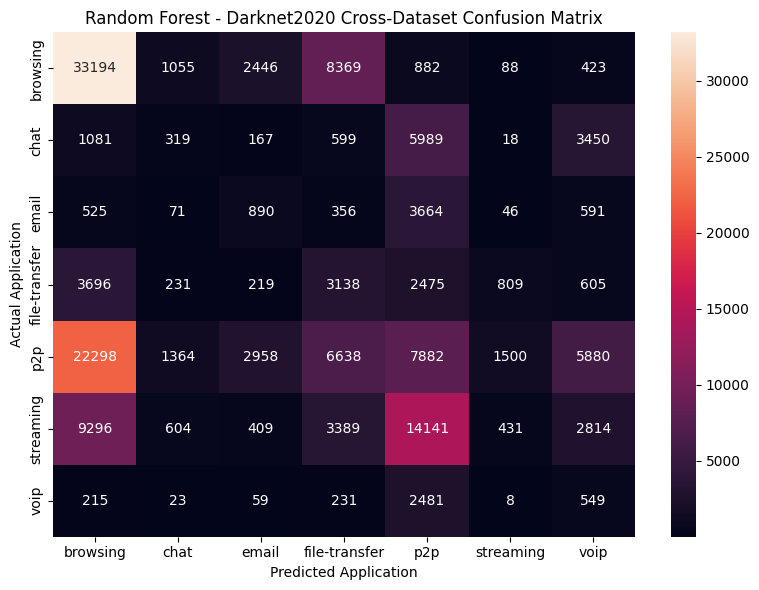

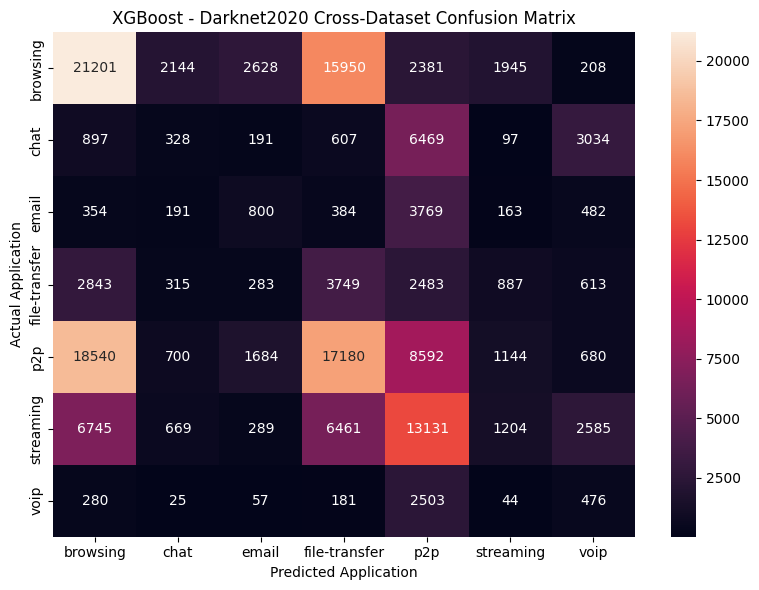

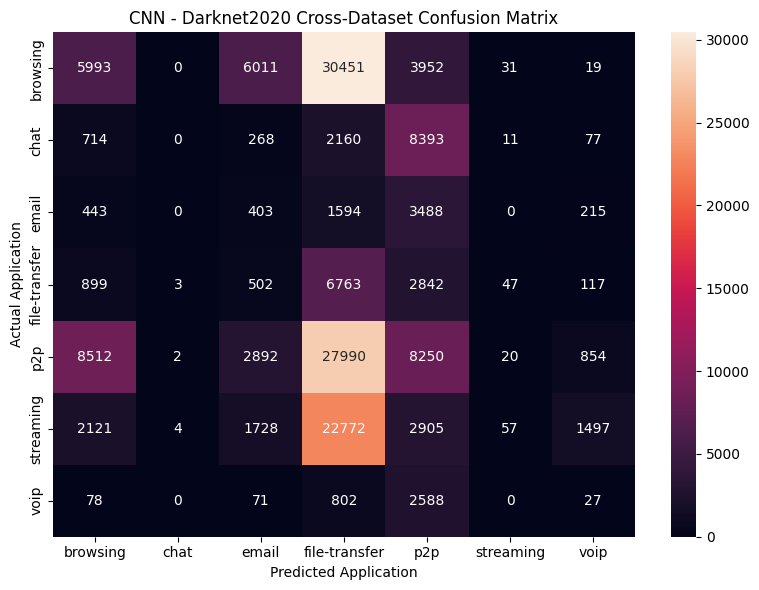

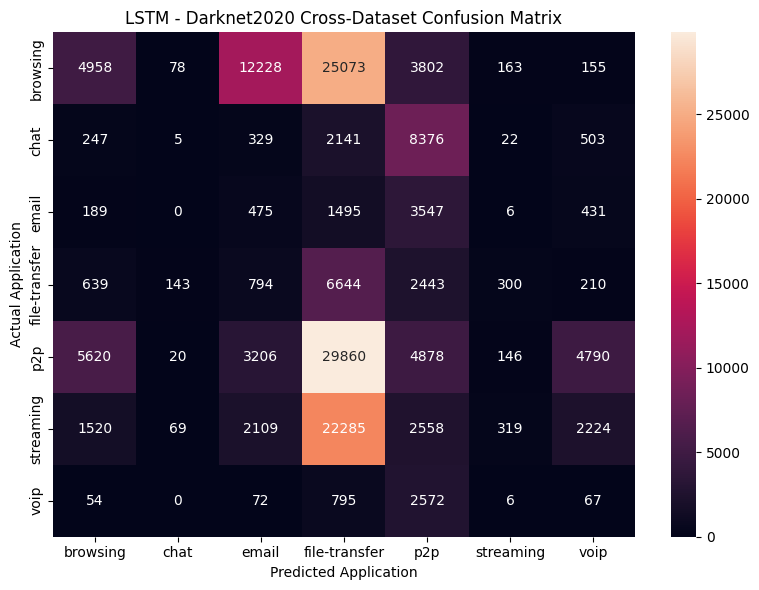

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

application_labels = [
    "browsing",
    "chat",
    "email",
    "file-transfer",
    "p2p",
    "streaming",
    "voip"
]

model_predictions = {
    "Random Forest": results["RF_Application"],
    "XGBoost": results["XGBoost_Application"],
    "CNN": results["CNN_Application"],
    "LSTM": results["LSTM_Application"]
}

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        results["Actual_Application"],
        predictions,
        labels=application_labels
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=application_labels,
        yticklabels=application_labels
    )

    plt.title(f"{model_name} - Darknet2020 Cross-Dataset Confusion Matrix")
    plt.xlabel("Predicted Application")
    plt.ylabel("Actual Application")
    plt.tight_layout()
    plt.show()

In [33]:
# Check whether all four models make the same application-level prediction

prediction_columns = [
    "RF_Application",
    "XGBoost_Application",
    "CNN_Application",
    "LSTM_Application"
]

results["All_Models_Agree"] = (
    results[prediction_columns].nunique(axis=1) == 1
)

agreement_rate = results["All_Models_Agree"].mean()

print(
    f"All-model agreement: "
    f"{agreement_rate:.4f} ({agreement_rate * 100:.2f}%)"
)

print("\nAgreement counts:")
print(results["All_Models_Agree"].value_counts())

All-model agreement: 0.2077 (20.77%)

Agreement counts:
All_Models_Agree
False    125637
True      32929
Name: count, dtype: int64


In [34]:
# Pairwise model agreement

pairs = [
    ("RF_Application", "XGBoost_Application"),
    ("RF_Application", "CNN_Application"),
    ("RF_Application", "LSTM_Application"),
    ("XGBoost_Application", "CNN_Application"),
    ("XGBoost_Application", "LSTM_Application"),
    ("CNN_Application", "LSTM_Application")
]

print("Pairwise Model Agreement")
print("------------------------")

for model_a, model_b in pairs:
    agreement = (
        results[model_a] == results[model_b]
    ).mean()

    print(
        f"{model_a.replace('_Application', '')} vs "
        f"{model_b.replace('_Application', '')}: "
        f"{agreement:.4f} ({agreement * 100:.2f}%)"
    )

Pairwise Model Agreement
------------------------
RF vs XGBoost: 0.6599 (65.99%)
RF vs CNN: 0.3038 (30.38%)
RF vs LSTM: 0.2641 (26.41%)
XGBoost vs CNN: 0.4155 (41.55%)
XGBoost vs LSTM: 0.3405 (34.05%)
CNN vs LSTM: 0.8551 (85.51%)


In [35]:
# Save complete cross-dataset prediction results

import os

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    RESULTS_DIR,
    "cic_darknet2020_cross_dataset_predictions.csv"
)

results.to_csv(OUTPUT_PATH, index=False)

print("Results saved successfully!")
print("File:", OUTPUT_PATH)
print("Rows:", len(results))
print("Columns:", len(results.columns))

Results saved successfully!
File: /Users/sheeba/Desktop/ML PROJECT/encrypted-traffic-classifier-xai/results/cic_darknet2020_cross_dataset_predictions.csv
Rows: 158566
Columns: 95


In [36]:
# Final summary of cross-dataset experiment

summary = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CNN",
        "LSTM"
    ],
    "Application_Level_Accuracy": [
        rf_accuracy,
        xgb_accuracy,
        cnn_accuracy,
        lstm_accuracy
    ]
})

summary["Accuracy_Percent"] = (
    summary["Application_Level_Accuracy"] * 100
)

print(summary.to_string(index=False))

print(f"\nAll-model agreement: {agreement_rate * 100:.2f}%")
print(f"Valid Darknet samples: {len(results)}")

        Model  Application_Level_Accuracy  Accuracy_Percent
Random Forest                    0.292642         29.264155
      XGBoost                    0.229242         22.924208
          CNN                    0.135546         13.554608
         LSTM                    0.109393         10.939293

All-model agreement: 20.77%
Valid Darknet samples: 158566
